In [1]:
from RandAR.dataset.nlcd_dataset import NLCDDataset

from matplotlib import pyplot as plt


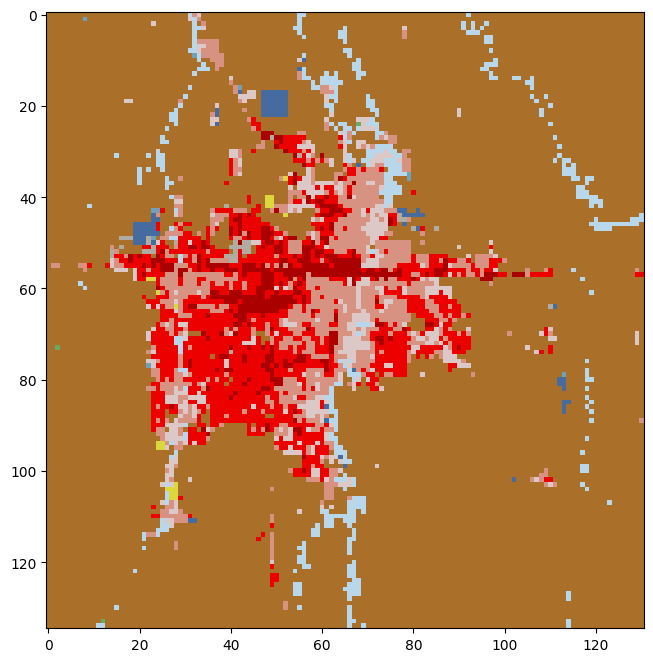

In [ ]:
bbox = [-96.9938, 46.7047, -96.5858, 46.9999]
downsample_ratio = 8
max_height = 128
max_width = 128

lulc, elev = NLCDDataset.extract(
    bbox=bbox,
    use_elevation=True,
    downsample_resolution=downsample_ratio,
    as_rgb=True
)

# Take middle `max_height` and `max_width` pixels from image center
lulc = lulc[
    lulc.shape[0] // 2 - max_height // 2: lulc.shape[0] // 2 + max_height // 2,
    lulc.shape[1] // 2 - max_width // 2: lulc.shape[1] // 2 + max_width // 2
]

elev = elev[
    elev.shape[0] // 2 - max_height // 2: elev.shape[0] // 2 + max_height // 2,
    elev.shape[1] // 2 - max_width // 2: elev.shape[1] // 2 + max_width // 2
]

plt.figure(figsize=(10,8))
plt.imshow(lulc)



In [ ]:
# Load the model and synthesize a new image
import torch
import numpy as np
import yaml
from pathlib import Path
import sys
sys.path.append('..')

from RandAR.utils import instantiate_from_config
from RandAR.utils.visualization import make_grid
import matplotlib.pyplot as plt

# Load configuration
config_path = Path("../configs/randar_nlcd_128_large.yaml")
with open(config_path, 'r') as f:
    config_dict = yaml.safe_load(f)

# Create a simple namespace to hold config
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            if isinstance(value, dict):
                setattr(self, key, Config(value))
            else:
                setattr(self, key, value)

config = Config(config_dict)

# Initialize model
print("Initializing model...")
model = instantiate_from_config(config.ar_model)

# Load checkpoint
checkpoint_path = Path("../results/models/randar_nlcd_128_large/checkpoints/iter_18000")
if checkpoint_path.exists():
    print(f"Loading checkpoint from {checkpoint_path}")
    
    # Load the accelerator state which includes the model
    model_state_file = checkpoint_path / "pytorch_model.bin"
    if model_state_file.exists():
        state_dict = torch.load(model_state_file, map_location='cpu')
        model.load_state_dict(state_dict)
        print("Model loaded successfully!")
    else:
        print(f"Model state file not found at {model_state_file}")
else:
    print(f"Checkpoint directory not found at {checkpoint_path}")

# Move model to CPU (or CUDA if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

print(f"Model on device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
# Generate new images
batch_size = 4  # Number of images to generate
image_size = 64  # Should match the tokenized image dimensions

# Create conditioning tokens (class labels)
# Using class 0 for unconditional generation
cond = torch.zeros(batch_size, 1, dtype=torch.long).to(device)

# Create auxiliary features (slope and aspect statistics)
# These would normally come from terrain data
# Using random values for demonstration
aux = torch.randn(batch_size, 2).to(device) * 0.1  # Small random aux features

print(f"Generating {batch_size} images...")

# Generate images
with torch.no_grad():
    gen_indices = model.generate(
        cond=cond,
        token_order=None,  # Use default ordering
        aux=aux,
        cfg_scales=[1.0, 1.0],  # No classifier-free guidance
        num_inference_steps=32,  # Number of denoising steps
        temperature=1.0,  # Sampling temperature
        top_k=0,  # No top-k filtering
        top_p=1.0,  # No nucleus sampling
    )

print(f"Generated token indices shape: {gen_indices.shape}")

# Clear any caches
model.remove_caches()

# The generated indices need to be decoded using the tokenizer
# For visualization, we'll reshape them
gen_images = gen_indices.cpu().numpy()
print(f"Generated images shape: {gen_images.shape}")

In [ ]:
# Load the tokenizer and decode table to convert tokens back to land cover values
data_path = Path("../data/data_128_final.npz")
if data_path.exists():
    print("Loading decode table...")
    data = np.load(data_path)
    decode_table = data.get('decode_table')
    
    if decode_table is not None:
        print(f"Decode table shape: {decode_table.shape}")
        
        # Decode the generated token indices
        # Assuming the model generates flattened sequences that need reshaping
        # The exact shape depends on the model's output format
        h, w = 64, 64  # Tokenized image dimensions
        
        # Reshape generated indices to image format
        gen_images_reshaped = gen_images.reshape(batch_size, h, w)
        
        # Decode tokens to actual land cover values
        decoded_images = []
        for i in range(batch_size):
            # Get the token indices for this image
            tokens = gen_images_reshaped[i].flatten()
            
            # Decode each token using the decode table
            # Each token maps to a 2x2 patch (assuming tokenizer_downsample_ratio=2)
            decoded_patches = decode_table[tokens]
            
            # Reshape to get the full resolution image
            # Assuming decode_table contains 2x2 patches
            D = 2  # tokenizer downsample ratio
            decoded = decoded_patches.reshape(h, w, D, D)
            decoded = decoded.transpose(0, 2, 1, 3).reshape(h*D, w*D)
            decoded_images.append(decoded)
        
        decoded_images = np.array(decoded_images)
        print(f"Decoded images shape: {decoded_images.shape}")
        
        # Convert to RGB for visualization using NLCD color mapping
        from RandAR.dataset.nlcd_dataset import NLCDDataset
        
        rgb_images = []
        for img in decoded_images:
            h, w = img.shape
            rgb_img = np.zeros((h, w, 3), dtype=np.float32)
            for class_id, rgb in NLCDDataset.NLCD_TO_RGB.items():
                mask = img == class_id
                rgb_img[mask] = rgb
            rgb_images.append(rgb_img)
        
        rgb_images = np.array(rgb_images)
        
        # Visualize the generated images
        fig, axes = plt.subplots(1, batch_size, figsize=(batch_size*4, 4))
        if batch_size == 1:
            axes = [axes]
        
        for i in range(batch_size):
            axes[i].imshow(rgb_images[i])
            axes[i].set_title(f'Generated Image {i+1}')
            axes[i].axis('off')
        
        plt.suptitle('Synthesized Land Cover Images', fontsize=16)
        plt.tight_layout()
        plt.show()
        
        # Also show the raw token indices as a heatmap
        fig, axes = plt.subplots(1, batch_size, figsize=(batch_size*4, 4))
        if batch_size == 1:
            axes = [axes]
        
        for i in range(batch_size):
            im = axes[i].imshow(decoded_images[i], cmap='tab20')
            axes[i].set_title(f'Land Cover Classes {i+1}')
            axes[i].axis('off')
        
        plt.suptitle('Generated Land Cover Class Labels', fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        print("No decode table found in the data file")
else:
    print(f"Data file not found at {data_path}")

In [ ]:
# Generate images with specific terrain conditions
# This demonstrates how to condition the generation on terrain features

print("\n" + "="*50)
print("Generating images with specific terrain conditions")
print("="*50)

# Create different terrain conditions
terrain_conditions = [
    {"name": "Flat terrain", "slope": 0.0, "aspect": 180.0},
    {"name": "Steep north-facing", "slope": 30.0, "aspect": 0.0},
    {"name": "Moderate east-facing", "slope": 15.0, "aspect": 90.0},
    {"name": "Steep south-facing", "slope": 30.0, "aspect": 180.0},
]

conditioned_images = []

for condition in terrain_conditions:
    print(f"\nGenerating for: {condition['name']}")
    print(f"  Slope: {condition['slope']}°, Aspect: {condition['aspect']}°")
    
    # Create auxiliary features for this condition
    # Normalize values as the model expects
    aux_single = torch.tensor([
        [condition['slope'] / 45.0,  # Normalize slope (0-45 degrees typical range)
         condition['aspect'] / 360.0]  # Normalize aspect (0-360 degrees)
    ], dtype=torch.float32).to(device)
    
    # Generate with specific terrain condition
    with torch.no_grad():
        gen_indices = model.generate(
            cond=torch.zeros(1, 1, dtype=torch.long).to(device),
            token_order=None,
            aux=aux_single,
            cfg_scales=[1.0, 1.0],
            num_inference_steps=32,
            temperature=0.8,  # Slightly lower temperature for more deterministic results
            top_k=50,  # Use top-k sampling for better quality
            top_p=0.95,
        )
    
    conditioned_images.append(gen_indices.cpu().numpy())
    model.remove_caches()

# Decode and visualize all conditioned images
if decode_table is not None:
    fig, axes = plt.subplots(1, len(terrain_conditions), figsize=(len(terrain_conditions)*4, 4))
    
    for i, (condition, gen_img) in enumerate(zip(terrain_conditions, conditioned_images)):
        # Reshape and decode
        tokens = gen_img.reshape(h, w).flatten()
        decoded_patches = decode_table[tokens]
        D = 2
        decoded = decoded_patches.reshape(h, w, D, D)
        decoded = decoded.transpose(0, 2, 1, 3).reshape(h*D, w*D)
        
        # Convert to RGB
        rgb_img = np.zeros((decoded.shape[0], decoded.shape[1], 3), dtype=np.float32)
        for class_id, rgb in NLCDDataset.NLCD_TO_RGB.items():
            mask = decoded == class_id
            rgb_img[mask] = rgb
        
        # Display
        axes[i].imshow(rgb_img)
        axes[i].set_title(f"{condition['name']}\nSlope: {condition['slope']}°, Aspect: {condition['aspect']}°", 
                         fontsize=10)
        axes[i].axis('off')
    
    plt.suptitle('Land Cover Generation Conditioned on Terrain Features', fontsize=14)
    plt.tight_layout()
    plt.show()

print("\nGeneration complete!")